In [ ]:
# -*- coding: utf-8 -*-
import urllib.request
import json
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

client_id = "id"
client_secret = "key"

url = "https://naverapihub.apigw.ntruss.com/search-trend/v1/search"

body = """{
    "startDate": "2024-01-01",
    "endDate": "2026-09-14",
    "timeUnit": "month",
    "keywordGroups": [
        {
            "groupName": "리센느",
            "keywords": ["리센느", "RESCENE"]
        },
        {
            "groupName": "아이오아이",
            "keywords": ["아이오아이","IOI"]
        }
    ]
}"""

In [1]:
request = urllib.request.Request(url)
request.add_header("X-NCP-APIGW-API-KEY-ID", client_id)
request.add_header("X-NCP-APIGW-API-KEY", client_secret)
request.add_header("Content-Type", "application/json")

response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()
if rescode == 200:
    result = json.loads(response.read().decode("utf-8"))
    print(result)
else:
    print("Error Code:" + str(rescode))

{'startDate': '2024-01-01', 'endDate': '2026-09-14', 'timeUnit': 'month', 'results': [{'title': '리센느', 'keywords': ['리센느', 'RESCENE'], 'data': [{'period': '2024-01-01', 'ratio': 0.02674}, {'period': '2024-02-01', 'ratio': 1.1691}, {'period': '2024-03-01', 'ratio': 2.61371}, {'period': '2024-04-01', 'ratio': 1.43253}, {'period': '2024-05-01', 'ratio': 1.12006}, {'period': '2024-06-01', 'ratio': 0.58014}, {'period': '2024-07-01', 'ratio': 0.62658}, {'period': '2024-08-01', 'ratio': 1.41229}, {'period': '2024-09-01', 'ratio': 6.27172}, {'period': '2024-10-01', 'ratio': 4.68949}, {'period': '2024-11-01', 'ratio': 1.46902}, {'period': '2024-12-01', 'ratio': 0.98868}, {'period': '2025-01-01', 'ratio': 1.06247}, {'period': '2025-02-01', 'ratio': 5.93882}, {'period': '2025-03-01', 'ratio': 6.74038}, {'period': '2025-04-01', 'ratio': 6.85372}, {'period': '2025-05-01', 'ratio': 6.66905}, {'period': '2025-06-01', 'ratio': 2.14518}, {'period': '2025-07-01', 'ratio': 3.93815}, {'period': '2025-08-0

In [2]:
equest = urllib.request.Request(url)
request.add_header("X-NCP-APIGW-API-KEY-ID", client_id)
request.add_header("X-NCP-APIGW-API-KEY", client_secret)
request.add_header("Content-Type", "application/json")

response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()
if rescode == 200:
    result = json.loads(response.read().decode("utf-8"))
    print(result)
else:
    print("Error Code:" + str(rescode))

{'startDate': '2024-01-01', 'endDate': '2026-09-14', 'timeUnit': 'month', 'results': [{'title': '리센느', 'keywords': ['리센느', 'RESCENE'], 'data': [{'period': '2024-01-01', 'ratio': 0.02674}, {'period': '2024-02-01', 'ratio': 1.1691}, {'period': '2024-03-01', 'ratio': 2.61371}, {'period': '2024-04-01', 'ratio': 1.43253}, {'period': '2024-05-01', 'ratio': 1.12006}, {'period': '2024-06-01', 'ratio': 0.58014}, {'period': '2024-07-01', 'ratio': 0.62658}, {'period': '2024-08-01', 'ratio': 1.41229}, {'period': '2024-09-01', 'ratio': 6.27172}, {'period': '2024-10-01', 'ratio': 4.68949}, {'period': '2024-11-01', 'ratio': 1.46902}, {'period': '2024-12-01', 'ratio': 0.98868}, {'period': '2025-01-01', 'ratio': 1.06247}, {'period': '2025-02-01', 'ratio': 5.93882}, {'period': '2025-03-01', 'ratio': 6.74038}, {'period': '2025-04-01', 'ratio': 6.85372}, {'period': '2025-05-01', 'ratio': 6.66905}, {'period': '2025-06-01', 'ratio': 2.14518}, {'period': '2025-07-01', 'ratio': 3.93815}, {'period': '2025-08-0

In [3]:
# 데이터프레임 만들기
df_list = []

for item in result["results"]:
    
    name = item["title"]

    temp = pd.DataFrame(item["data"])
    temp["period"] = pd.to_datetime(temp["period"])
    temp["검색어"] = name
    
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df.head()

,period,ratio,검색어
0,2024-01-01,0.02674,리센느
1,2024-02-01,1.16910,리센느
2,2024-03-01,2.61371,리센느
3,2024-04-01,1.43253,리센느
4,2024-05-01,1.12006,리센느


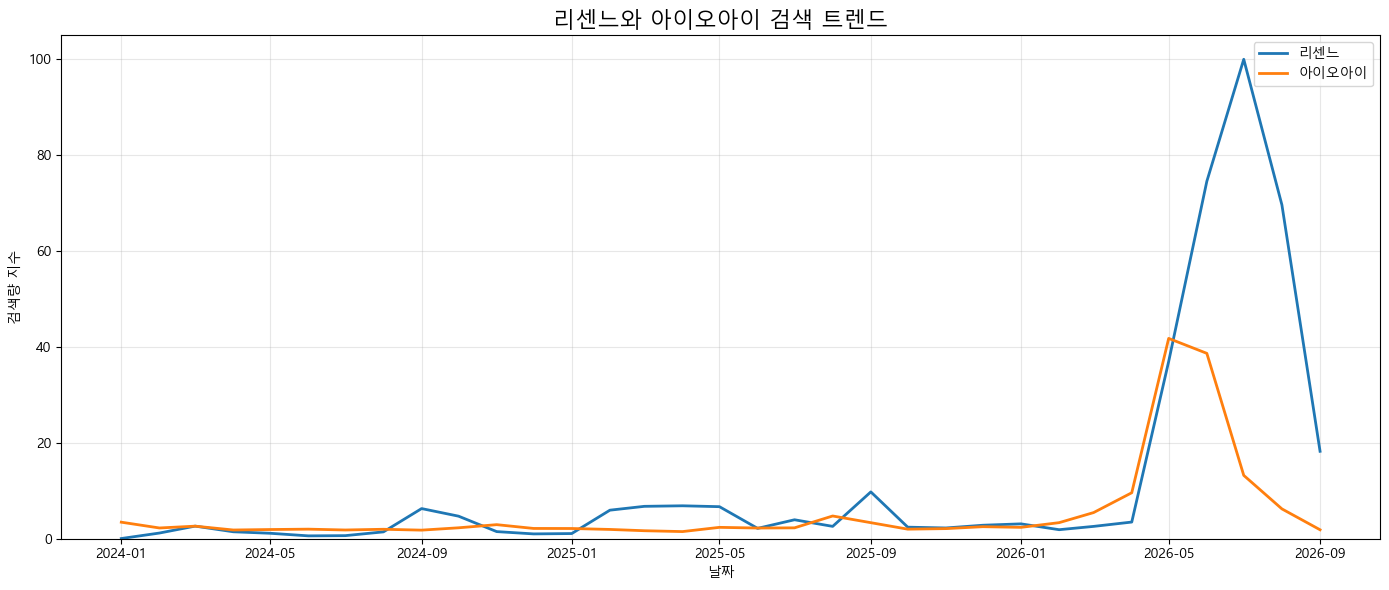

In [4]:
# 그래프 그리기
plt.figure(figsize=(14, 6))

for name in df["검색어"].unique():
    
    temp = df[df["검색어"] == name]
    
    plt.plot(
        temp["period"],
        temp["ratio"],
        label=name,
        linewidth=2
    )


plt.title(
    "리센느와 아이오아이 검색 트렌드",
    fontsize=16
)

plt.xlabel("날짜")
plt.ylabel("검색량 지수")

plt.ylim(0, 105)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()